n=24  train: 2001–2017 (17 obs)  test: 2018–2024 (7 obs)

OOB R²: 0.337
Train (2001–2017)       MAE=1.852  RMSE=2.287  R²=0.737
Test  (2018–2024)       MAE=2.239  RMSE=2.991  R²=-0.054

Важность признаков:
unemployment    0.267
gov_exp         0.217
tax_rev         0.117
econ_free       0.110
lag_gdp         0.085
fdi             0.064
inflation       0.060
wgi             0.057
trade_open      0.022


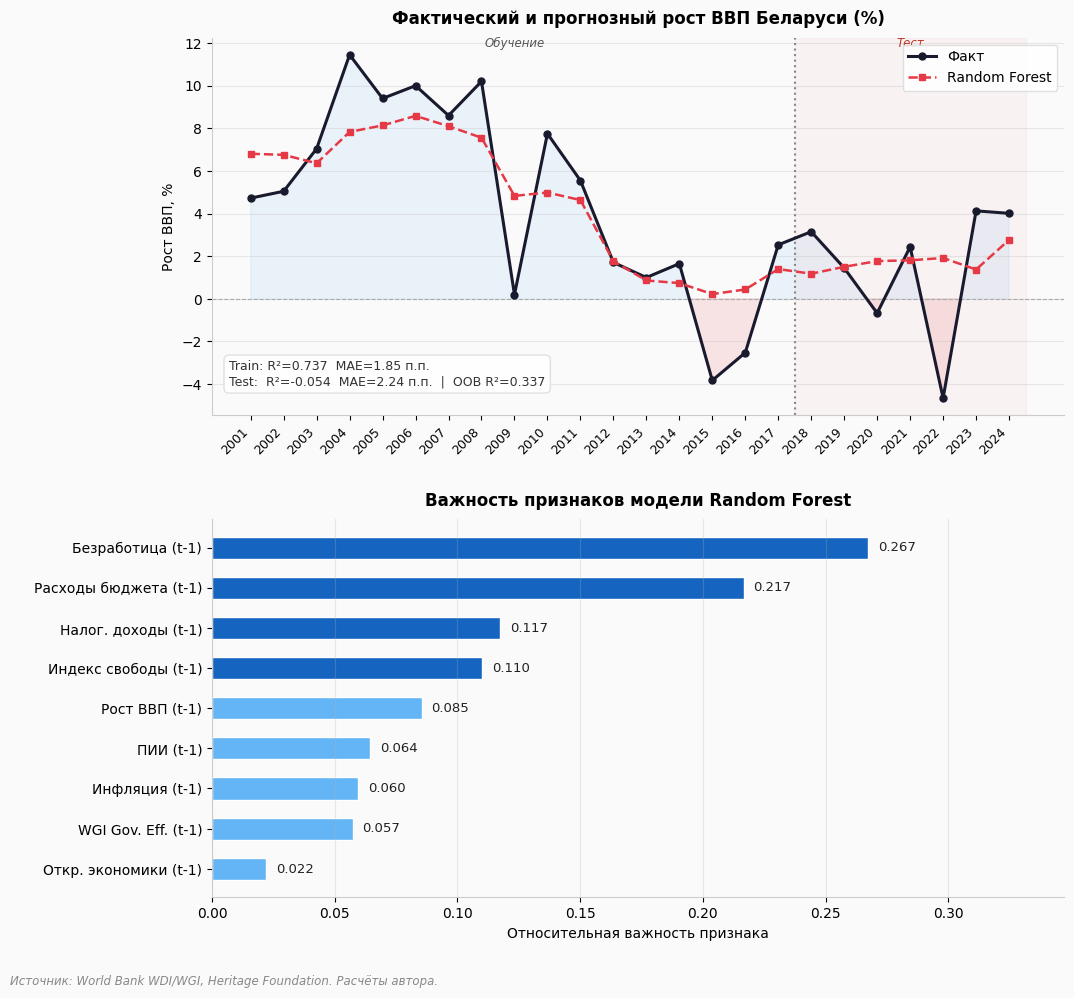

In [7]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

# ── данные ──
df_ml = pd.read_excel('data.xlsx', sheet_name='Data_ML')
df_ml = df_ml.rename(columns={
    'Year': 'year',
    'GDP Growth (%) — TARGET': 'gdp_growth',
    'Lag GDP Growth t-1 (%)': 'lag_gdp',
    'Inflation CPI t-1 (%)': 'inflation',
    'Unemployment t-1 (%)': 'unemployment',
    'Gov. Expenditure t-1 (% GDP)': 'gov_exp',
    'Tax Revenue t-1 (% GDP)': 'tax_rev',
    'Trade Openness t-1 (% GDP)': 'trade_open',
    'FDI Inflows t-1 (% GDP)': 'fdi',
    'WGI Gov. Eff. t-1': 'wgi',
    'Econ. Freedom t-1': 'econ_free',
})
df_ml = df_ml[pd.to_numeric(df_ml['year'], errors='coerce').notna()].copy()
df_ml['year'] = df_ml['year'].astype(int)
for c in df_ml.columns[1:]:
    df_ml[c] = pd.to_numeric(df_ml[c], errors='coerce')

cols = ['lag_gdp','inflation','unemployment','gov_exp','tax_rev',
        'trade_open','fdi','wgi','econ_free']

data  = df_ml[['year','gdp_growth']+cols].dropna().reset_index(drop=True)
y     = data['gdp_growth'].values.astype(float)
X     = data[cols].values.astype(float)
yrs   = data['year'].values
n     = len(data)
split = 17  # train 2001–2017 (17 obs), test 2018–2024 (7 obs)

print(f"n={n}  train: {yrs[0]}–{yrs[split-1]} ({split} obs)  test: {yrs[split]}–{yrs[-1]} ({n-split} obs)")

# ── модель ──
rf = RandomForestRegressor(
    n_estimators=300, max_depth=3, min_samples_leaf=3,
    min_samples_split=5, max_features='sqrt',
    bootstrap=True, oob_score=True, random_state=42
)
rf.fit(X[:split], y[:split])

p_tr  = rf.predict(X[:split])
p_te  = rf.predict(X[split:])
p_all = np.concatenate([p_tr, p_te])

def metrics(yt, yp, label):
    mae  = mean_absolute_error(yt, yp)
    rmse = np.sqrt(mean_squared_error(yt, yp))
    r2   = r2_score(yt, yp)
    print(f"{label:22s}  MAE={mae:.3f}  RMSE={rmse:.3f}  R²={r2:.3f}")
    return mae, rmse, r2

print(f"\nOOB R²: {rf.oob_score_:.3f}")
tr_m = metrics(y[:split], p_tr, f"Train (2001–{yrs[split-1]})")
te_m = metrics(y[split:], p_te, f"Test  ({yrs[split]}–{yrs[-1]})")

fi = pd.Series(rf.feature_importances_, index=cols).sort_values(ascending=False)
print("\nВажность признаков:")
print(fi.round(3).to_string())

# ── график ──
plt.rcParams.update({'font.family': 'DejaVu Sans',
                     'axes.spines.top': False, 'axes.spines.right': False})

fig, axes = plt.subplots(2, 1, figsize=(11, 10))
fig.patch.set_facecolor('#fafafa')

ax = axes[0]
ax.set_facecolor('#fafafa')
ax.fill_between(yrs, y, 0, where=(y < 0), alpha=0.12, color='#e63946', interpolate=True)
ax.fill_between(yrs, y, 0, where=(y >= 0), alpha=0.07, color='#2196F3', interpolate=True)
ax.plot(yrs, y,     'o-',  color='#1a1a2e', lw=2.2, ms=5, zorder=3, label='Факт')
ax.plot(yrs, p_all, 's--', color='#e63946', lw=1.8, ms=4, zorder=3, label='Random Forest')
ax.axvspan(yrs[split] - 0.5, yrs[-1] + 0.5, alpha=0.04, color='#e63946')
ax.axvline(yrs[split] - 0.5, color='#888', ls=':', lw=1.5)
ax.text(yrs[split//2], y.max() + 0.4, 'Обучение', ha='center', fontsize=8.5,
        color='#555', style='italic')
ax.text(yrs[split + (n-split)//2], y.max() + 0.4, 'Тест', ha='center', fontsize=8.5,
        color='#c0392b', style='italic')
ax.axhline(0, color='#aaa', lw=0.8, ls='--')
ax.set_title('Фактический и прогнозный рост ВВП Беларуси (%)',
             fontsize=12, fontweight='bold', pad=10)
ax.set_ylabel('Рост ВВП, %', fontsize=10)
ax.legend(fontsize=10, framealpha=0.9, edgecolor='#ddd', loc='upper right')
ax.set_xticks(yrs)
ax.set_xticklabels(yrs.astype(int), rotation=45, ha='right', fontsize=9)
ax.spines['left'].set_color('#ccc'); ax.spines['bottom'].set_color('#ccc')
ax.grid(axis='y', alpha=0.25)
ax.text(0.02, 0.08,
        f"Train: R²={tr_m[2]:.3f}  MAE={tr_m[0]:.2f} п.п.\n"
        f"Test:  R²={te_m[2]:.3f}  MAE={te_m[0]:.2f} п.п.  |  OOB R²={rf.oob_score_:.3f}",
        transform=ax.transAxes, fontsize=9, color='#333',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                  edgecolor='#ddd', alpha=0.9))

ax2 = axes[1]
ax2.set_facecolor('#fafafa')
fi_labels = {
    'unemployment':'Безработица (t-1)', 'gov_exp':'Расходы бюджета (t-1)',
    'tax_rev':'Налог. доходы (t-1)', 'econ_free':'Индекс свободы (t-1)',
    'fdi':'ПИИ (t-1)', 'inflation':'Инфляция (t-1)',
    'lag_gdp':'Рост ВВП (t-1)', 'wgi':'WGI Gov. Eff. (t-1)',
    'trade_open':'Откр. экономики (t-1)'
}
fi_ru = fi.rename(fi_labels)
col_fi = ['#1565C0' if v >= 0.1 else '#64B5F6' for v in fi_ru.values]
bars = ax2.barh(fi_ru.index, fi_ru.values, color=col_fi, edgecolor='white', height=0.55)
for bar, val in zip(bars, fi_ru.values):
    ax2.text(val + 0.004, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', ha='left', fontsize=9.5, color='#222')
ax2.set_title('Важность признаков модели Random Forest',
              fontsize=12, fontweight='bold', pad=10)
ax2.set_xlabel('Относительная важность признака', fontsize=10)
ax2.set_xlim(0, fi_ru.max() + 0.08)
ax2.invert_yaxis()
ax2.spines['left'].set_color('#ccc'); ax2.spines['bottom'].set_color('#ccc')
ax2.grid(axis='x', alpha=0.25)
ax2.tick_params(axis='y', labelsize=10)

fig.text(0.01, -0.01,
         'Источник: World Bank WDI/WGI, Heritage Foundation. Расчёты автора.',
         fontsize=8.5, color='#888', style='italic')

plt.tight_layout(pad=2.5)
plt.savefig('rf_final.png', dpi=300, bbox_inches='tight', facecolor='#fafafa')
plt.show()

n=24  (полная выборка: 2001–2024)

Full sample: MAE=1.866  RMSE=2.280  R²=0.725
OOB R²: 0.303

Важность признаков:
unemployment    0.262
gov_exp         0.197
tax_rev         0.125
econ_free       0.119
lag_gdp         0.098
wgi             0.071
fdi             0.070
trade_open      0.031
inflation       0.028


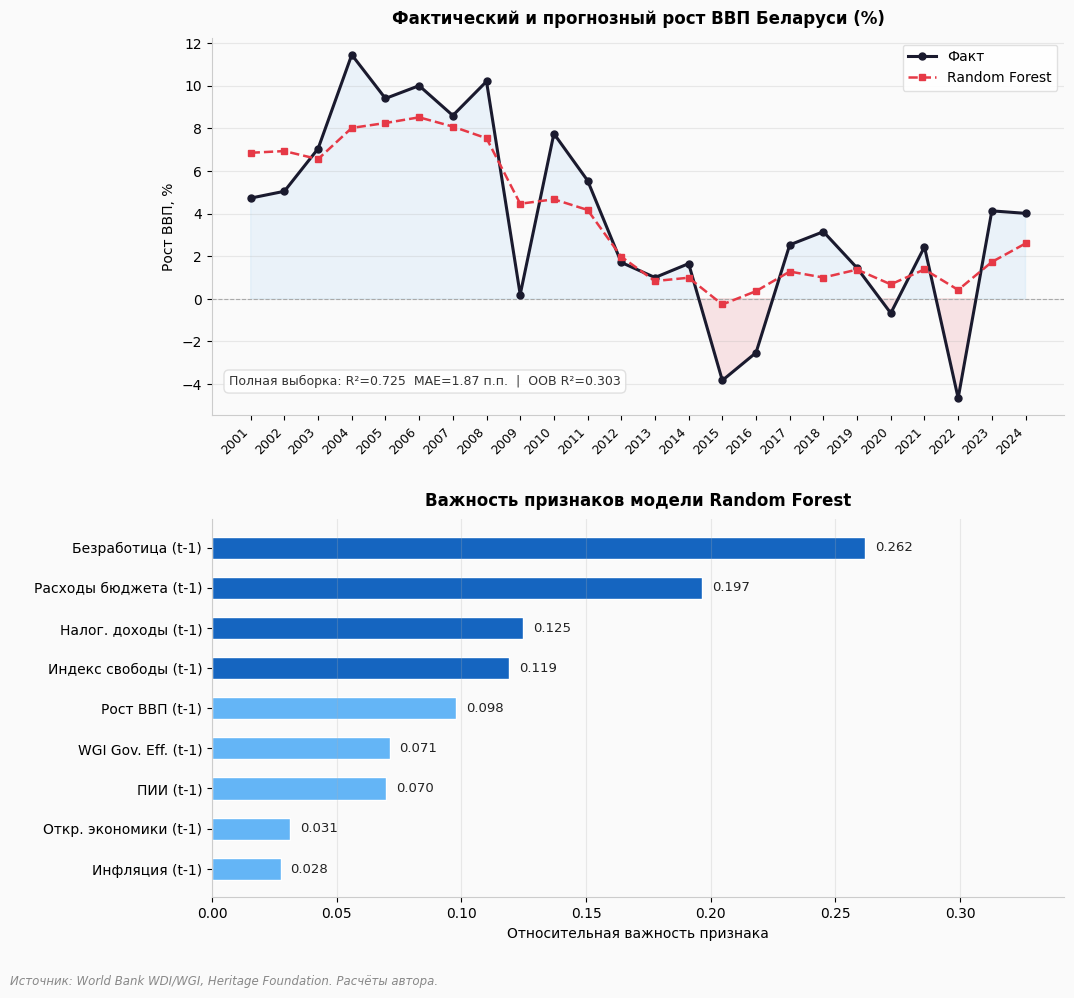

In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

# ── данные ──
df_ml = pd.read_excel('data.xlsx', sheet_name='Data_ML')
df_ml = df_ml.rename(columns={
    'Year': 'year',
    'GDP Growth (%) — TARGET': 'gdp_growth',
    'Lag GDP Growth t-1 (%)': 'lag_gdp',
    'Inflation CPI t-1 (%)': 'inflation',
    'Unemployment t-1 (%)': 'unemployment',
    'Gov. Expenditure t-1 (% GDP)': 'gov_exp',
    'Tax Revenue t-1 (% GDP)': 'tax_rev',
    'Trade Openness t-1 (% GDP)': 'trade_open',
    'FDI Inflows t-1 (% GDP)': 'fdi',
    'WGI Gov. Eff. t-1': 'wgi',
    'Econ. Freedom t-1': 'econ_free',
})
df_ml = df_ml[pd.to_numeric(df_ml['year'], errors='coerce').notna()].copy()
df_ml['year'] = df_ml['year'].astype(int)
for c in df_ml.columns[1:]:
    df_ml[c] = pd.to_numeric(df_ml[c], errors='coerce')

cols = ['lag_gdp','inflation','unemployment','gov_exp','tax_rev',
        'trade_open','fdi','wgi','econ_free']

data = df_ml[['year','gdp_growth'] + cols].dropna().reset_index(drop=True)
y    = data['gdp_growth'].values.astype(float)
X    = data[cols].values.astype(float)
yrs  = data['year'].values
n    = len(data)

print(f"n={n}  (полная выборка: {yrs[0]}–{yrs[-1]})")

# ── модель на всей выборке ──
rf = RandomForestRegressor(
    n_estimators=300, max_depth=3, min_samples_leaf=3,
    min_samples_split=5, max_features='sqrt',
    bootstrap=True, oob_score=True, random_state=42
)
rf.fit(X, y)

p_all = rf.predict(X)

mae  = mean_absolute_error(y, p_all)
rmse = np.sqrt(mean_squared_error(y, p_all))
r2   = r2_score(y, p_all)

print(f"\nFull sample: MAE={mae:.3f}  RMSE={rmse:.3f}  R²={r2:.3f}")
print(f"OOB R²: {rf.oob_score_:.3f}")

fi = pd.Series(rf.feature_importances_, index=cols).sort_values(ascending=False)
print("\nВажность признаков:")
print(fi.round(3).to_string())

# ── график ──
plt.rcParams.update({'font.family': 'DejaVu Sans',
                     'axes.spines.top': False, 'axes.spines.right': False})

fig, axes = plt.subplots(2, 1, figsize=(11, 10))
fig.patch.set_facecolor('#fafafa')

# 1) факт vs прогноз (полная выборка)
ax = axes[0]
ax.set_facecolor('#fafafa')
ax.fill_between(yrs, y, 0, where=(y < 0), alpha=0.12,
                color='#e63946', interpolate=True)
ax.fill_between(yrs, y, 0, where=(y >= 0), alpha=0.07,
                color='#2196F3', interpolate=True)
ax.plot(yrs, y,     'o-',  color='#1a1a2e', lw=2.2, ms=5,
        zorder=3, label='Факт')
ax.plot(yrs, p_all, 's--', color='#e63946', lw=1.8, ms=4,
        zorder=3, label='Random Forest')

ax.axhline(0, color='#aaa', lw=0.8, ls='--')
ax.set_title('Фактический и прогнозный рост ВВП Беларуси (%)',
             fontsize=12, fontweight='bold', pad=10)
ax.set_ylabel('Рост ВВП, %', fontsize=10)
ax.legend(fontsize=10, framealpha=0.9, edgecolor='#ddd', loc='upper right')
ax.set_xticks(yrs)
ax.set_xticklabels(yrs.astype(int), rotation=45, ha='right', fontsize=9)
ax.spines['left'].set_color('#ccc'); ax.spines['bottom'].set_color('#ccc')
ax.grid(axis='y', alpha=0.25)
ax.text(0.02, 0.08,
        f"Полная выборка: R²={r2:.3f}  MAE={mae:.2f} п.п.  |  OOB R²={rf.oob_score_:.3f}",
        transform=ax.transAxes, fontsize=9, color='#333',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                  edgecolor='#ddd', alpha=0.9))

# 2) важность признаков
ax2 = axes[1]
ax2.set_facecolor('#fafafa')
fi_labels = {
    'unemployment':'Безработица (t-1)', 'gov_exp':'Расходы бюджета (t-1)',
    'tax_rev':'Налог. доходы (t-1)', 'econ_free':'Индекс свободы (t-1)',
    'fdi':'ПИИ (t-1)', 'inflation':'Инфляция (t-1)',
    'lag_gdp':'Рост ВВП (t-1)', 'wgi':'WGI Gov. Eff. (t-1)',
    'trade_open':'Откр. экономики (t-1)'
}
fi_ru = fi.rename(fi_labels)
col_fi = ['#1565C0' if v >= 0.1 else '#64B5F6' for v in fi_ru.values]
bars = ax2.barh(fi_ru.index, fi_ru.values,
                color=col_fi, edgecolor='white', height=0.55)
for bar, val in zip(bars, fi_ru.values):
    ax2.text(val + 0.004, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', ha='left',
             fontsize=9.5, color='#222')
ax2.set_title('Важность признаков модели Random Forest',
              fontsize=12, fontweight='bold', pad=10)
ax2.set_xlabel('Относительная важность признака', fontsize=10)
ax2.set_xlim(0, fi_ru.max() + 0.08)
ax2.invert_yaxis()
ax2.spines['left'].set_color('#ccc'); ax2.spines['bottom'].set_color('#ccc')
ax2.grid(axis='x', alpha=0.25)
ax2.tick_params(axis='y', labelsize=10)

fig.text(0.01, -0.01,
         'Источник: World Bank WDI/WGI, Heritage Foundation. Расчёты автора.',
         fontsize=8.5, color='#888', style='italic')

plt.tight_layout(pad=2.5)
plt.savefig('rf_full_sample.png', dpi=300,
            bbox_inches='tight', facecolor='#fafafa')
plt.show()